In [1]:
# Cell 1: Deep Learning Environment, Data Aggregation, and Scaling
import os
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Device Configuration: Force PyTorch to use the discrete GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Compute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Model: {torch.cuda.get_device_name(0)}\n")

# 2. Big Data Aggregation: Combining multiple device logs
DATASET_DIR = "./dataset/GothamDataset2025/processed/"
# You can add more files to this list later to scale up
files_to_load = [
    'iotsim-air-quality-1.csv', 
    'iotsim-building-monitor-1.csv', 
    'iotsim-garage-door-1.csv'
]

df_list = []
for f in files_to_load:
    path = os.path.join(DATASET_DIR, f)
    if os.path.exists(path):
        df_list.append(pd.read_csv(path))
    else:
        print(f"Warning: {f} not found in directory.")

df_combined = pd.concat(df_list, ignore_index=True)
print(f"Aggregated Dataset Shape: {df_combined.shape}")

# 3. Comprehensive Preprocessing (Inherited from Phase 1)
columns_to_drop = ['frame.time', 'eth.src', 'eth.dst', 'ip.src', 'ip.dst', 'frame.protocols', 'tcp.options', 'ip.checksum', 'tcp.checksum']
df_clean = df_combined.drop(columns=columns_to_drop, errors='ignore').fillna(0)

def hex_to_int(val):
    try:
        if isinstance(val, str) and val.startswith('0x'): return int(val, 16)
        return float(val)
    except: return 0

df_clean['ip.flags'] = df_clean['ip.flags'].apply(hex_to_int)
df_clean['tcp.flags'] = df_clean['tcp.flags'].apply(hex_to_int)

# 4. Feature Isolation and Stratified Partitioning
X = df_clean.drop(columns=['label']).values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Crucial Deep Learning Step: Feature Scaling (Z-score Normalization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Test set MUST be scaled using the scaler fitted ONLY on the training set to prevent data leakage
X_test_scaled = scaler.transform(X_test)

print("\nStatus: PyTorch Data Pipeline Ready.")
print(f"Training Features Dimensions: {X_train_scaled.shape}")
print(f"Total Unique Attack Classes: {len(label_encoder.classes_)}")

Active Compute Device: cuda
GPU Model: NVIDIA GeForce RTX 3050 Laptop GPU



C:\Users\Nguyen Xuan Hung\AppData\Local\Temp\ipykernel_17152\1605947203.py:28: DtypeWarning: Columns (0: tcp.flags, 1: tcp.checksum, 2: tcp.options) have mixed types. Specify dtype option on import or set low_memory=False.
  df_list.append(pd.read_csv(path))


Aggregated Dataset Shape: (5606039, 23)

Status: PyTorch Data Pipeline Ready.
Training Features Dimensions: (4484831, 13)
Total Unique Attack Classes: 16


In [2]:
# Cell 2: PyTorch DataLoader Initialization and DNN Architecture Formulation
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# 1. Tensor Conversion and Device Allocation (Moving data to RTX 3050)
# Using float32 for feature matrices and int64 (long) for target labels
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

# 2. DataLoader Configuration for Mini-batch Gradient Descent
# A large batch size (4096) is utilized to maximize GPU VRAM throughput for 4.4M+ instances
BATCH_SIZE = 4096

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders initialized. Total training batches per epoch: {len(train_loader)}")

# 3. Define the Deep Neural Network (DNN) Blueprint
class IoTIntrusionDNN(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(IoTIntrusionDNN, self).__init__()
        self.network = nn.Sequential(
            # First Hidden Layer
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Second Hidden Layer
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Output Layer (Raw logits, CrossEntropyLoss handles Softmax implicitly)
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        return self.network(x)

# 4. Model Instantiation
input_dimension = X_train_scaled.shape[1]
number_of_classes = len(label_encoder.classes_)

model_baseline = IoTIntrusionDNN(input_dim=input_dimension, num_classes=number_of_classes).to(device)

print("\nBaseline DNN Architecture successfully deployed to GPU:")
print(model_baseline)

DataLoaders initialized. Total training batches per epoch: 1095

Baseline DNN Architecture successfully deployed to GPU:
IoTIntrusionDNN(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=16, bias=True)
  )
)


In [3]:
# Cell 3: DNN Training Loop and Scalable Evaluation (VRAM-Optimized)
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report

# 1. Hyperparameter Configuration
EPOCHS = 5
LEARNING_RATE = 0.001

# Loss function tailored for multi-class classification
# Note: CrossEntropyLoss intrinsically applies LogSoftmax, so raw logits from the model are expected
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=LEARNING_RATE)

# 2. Training Loop Execution
print(f"Initiating Deep Learning Training Phase ({EPOCHS} Epochs)...")
for epoch in range(EPOCHS):
    model_baseline.train()
    running_loss = 0.0
    
    # Utilizing tqdm for real-time progress tracking across 1095 batches
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', unit='batch')
    
    for inputs, targets in progress_bar:
        # Zero the parameter gradients to prevent accumulation
        optimizer.zero_grad()
        
        # Forward pass: Compute predicted outputs by passing inputs to the model
        outputs = model_baseline(inputs)
        
        # Calculate the batch loss
        loss = criterion(outputs, targets)
        
        # Backward pass: Compute gradient of the loss with respect to model parameters
        loss.backward()
        
        # Perform a single optimization step (parameter update)
        optimizer.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix({'loss': running_loss / (progress_bar.n + 1)})

# 3. Scalable Evaluation Phase (Preventing Out-of-Memory / OOM errors)
print("\nExecuting VRAM-optimized Inference on Unseen Testing Set...")
model_baseline.eval()
all_predictions = []
all_ground_truth = []

# Disable gradient calculation for memory efficiency during inference
with torch.no_grad():
    for inputs, targets in tqdm(test_loader, desc="Evaluating", unit="batch"):
        outputs = model_baseline(inputs)
        # Identify the class with the highest probability
        _, predicted = torch.max(outputs.data, 1)
        
        # Transfer batch results back to CPU RAM for scikit-learn compatibility
        all_predictions.extend(predicted.cpu().numpy())
        all_ground_truth.extend(targets.cpu().numpy())

# 4. Comprehensive Performance Metrics Output
print("\nDeep Learning Baseline Model Evaluation (Classification Report):")
print(classification_report(all_ground_truth, all_predictions, target_names=label_encoder.classes_, zero_division=0))

Initiating Deep Learning Training Phase (5 Epochs)...


Epoch 5/5: 100%|███████████████████████████████████████████████████| 1095/1095 [00:45<00:00, 23.83batch/s, loss=0.0145]



Executing VRAM-optimized Inference on Unseen Testing Set...


Evaluating: 100%|█████████████████████████████████████████████████████████████████| 274/274 [00:08<00:00, 32.03batch/s]



Deep Learning Baseline Model Evaluation (Classification Report):
                          precision    recall  f1-score   support

                  Benign       0.99      0.94      0.96      2728
       C&C Communication       0.00      0.00      0.00        17
           File Download       1.00      0.60      0.75       238
   Ingress Tool Transfer       0.99      0.62      0.76       773
Merlin C&C Communication       1.00      0.97      0.98      1931
    Merlin ICMP Flooding       1.00      1.00      1.00      1830
     Merlin TCP Flooding       0.88      0.97      0.92      4000
     Merlin UDP Flooding       0.81      1.00      0.89      1000
 Mirai C&C Communication       0.00      0.00      0.00        72
      Mirai GRE Flooding       1.00      1.00      1.00    300462
      Mirai TCP Flooding       1.00      1.00      1.00    293714
      Mirai UDP Flooding       1.00      1.00      1.00    476317
               Reporting       0.00      0.00      0.00        17
         

In [4]:
# Cell 4: Advanced Algorithmic Resilience - Implementing Focal Loss for Extreme Imbalance
import torch.nn.functional as F

# 1. Mathematical formulation of Focal Loss for Multi-class Deep Learning
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha # Class weights to handle frequency distribution

    def forward(self, inputs, targets):
        # Calculate standard Cross Entropy Loss (unreduced to apply weights per instance)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        # Calculate probability of the true class (pt)
        pt = torch.exp(-ce_loss)
        # Apply the modulating factor: (1 - pt)^gamma
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

# 2. Dynamic Alpha Calculation (Inverse Class Frequency)
# Heavily penalizes majority classes (Flooding) and boosts minority classes (C&C, Reporting)
class_counts = np.bincount(y_train)
class_weights = 1.0 / (class_counts + 1e-6) # Add epsilon to prevent division by zero
class_weights = class_weights / class_weights.sum() * len(class_counts) # Normalize
alpha_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

# 3. Model Re-initialization for an isolated training run
# Resetting weights to ensure Focal Loss trains from scratch, not continuing from Baseline
model_resilient = IoTIntrusionDNN(input_dim=input_dimension, num_classes=number_of_classes).to(device)

# 4. Training Configuration with Focal Loss
criterion_focal = FocalLoss(alpha=alpha_tensor, gamma=2.0)
optimizer_resilient = optim.Adam(model_resilient.parameters(), lr=LEARNING_RATE)

print(f"Initiating Resilient Training Phase with Focal Loss ({EPOCHS} Epochs)...")
for epoch in range(EPOCHS):
    model_resilient.train()
    running_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', unit='batch')
    
    for inputs, targets in progress_bar:
        optimizer_resilient.zero_grad()
        outputs = model_resilient(inputs)
        
        # Apply our custom Focal Loss
        loss = criterion_focal(outputs, targets)
        loss.backward()
        optimizer_resilient.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix({'focal_loss': running_loss / (progress_bar.n + 1)})

# 5. Scalable Evaluation Phase
print("\nExecuting Inference with Resilient Model...")
model_resilient.eval()
all_predictions_resilient = []

with torch.no_grad():
    for inputs, targets in tqdm(test_loader, desc="Evaluating", unit="batch"):
        outputs = model_resilient(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions_resilient.extend(predicted.cpu().numpy())

print("\nResilient Model Evaluation (Classification Report with Focal Loss):")
print(classification_report(all_ground_truth, all_predictions_resilient, target_names=label_encoder.classes_, zero_division=0))

Initiating Resilient Training Phase with Focal Loss (5 Epochs)...


Epoch 5/5: 100%|████████████████████████████████████████████| 1095/1095 [00:47<00:00, 23.07batch/s, focal_loss=9.44e-5]



Executing Inference with Resilient Model...


Evaluating: 100%|█████████████████████████████████████████████████████████████████| 274/274 [00:08<00:00, 30.63batch/s]



Resilient Model Evaluation (Classification Report with Focal Loss):
                          precision    recall  f1-score   support

                  Benign       0.02      0.77      0.03      2728
       C&C Communication       0.00      0.88      0.00        17
           File Download       0.00      0.60      0.00       238
   Ingress Tool Transfer       0.01      0.49      0.01       773
Merlin C&C Communication       0.15      0.17      0.16      1931
    Merlin ICMP Flooding       0.03      1.00      0.05      1830
     Merlin TCP Flooding       0.11      1.00      0.20      4000
     Merlin UDP Flooding       0.01      1.00      0.02      1000
 Mirai C&C Communication       0.00      1.00      0.00        72
      Mirai GRE Flooding       0.00      0.00      0.00    300462
      Mirai TCP Flooding       0.00      0.00      0.00    293714
      Mirai UDP Flooding       0.00      0.00      0.00    476317
               Reporting       0.00      1.00      0.00        17
      

In [5]:
# Cell 5: Taming the Focal Loss with Logarithmic Smoothing

# 1. Logarithmic Smoothing for Alpha Weights
# Instead of extreme raw inverse frequencies, we apply log to smooth out the massive peaks
smoothed_counts = np.log1p(class_counts) 
class_weights_smoothed = 1.0 / smoothed_counts

# Normalize the weights
class_weights_smoothed = class_weights_smoothed / class_weights_smoothed.sum() * len(class_counts)

# Clip extreme values to prevent the 'Paranoid AI' effect (capping max penalty)
class_weights_smoothed = np.clip(class_weights_smoothed, a_min=0.1, a_max=10.0)

alpha_tensor_smoothed = torch.tensor(class_weights_smoothed, dtype=torch.float32).to(device)

print("Status: Smoothed Alpha Weights calculated.")
print(f"Max weight: {class_weights_smoothed.max():.2f}, Min weight: {class_weights_smoothed.min():.2f}\n")

# 2. Re-initialize a fresh model to clear the 'paranoid' memory
model_resilient_v2 = IoTIntrusionDNN(input_dim=input_dimension, num_classes=number_of_classes).to(device)

# 3. Training Configuration with Smoothed Focal Loss
criterion_focal_v2 = FocalLoss(alpha=alpha_tensor_smoothed, gamma=2.0)
optimizer_resilient_v2 = optim.Adam(model_resilient_v2.parameters(), lr=LEARNING_RATE)

print(f"Initiating Resilient Training Phase with Smoothed Focal Loss ({EPOCHS} Epochs)...")
for epoch in range(EPOCHS):
    model_resilient_v2.train()
    running_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}', unit='batch')
    
    for inputs, targets in progress_bar:
        optimizer_resilient_v2.zero_grad()
        outputs = model_resilient_v2(inputs)
        
        # Apply the tamed Focal Loss
        loss = criterion_focal_v2(outputs, targets)
        loss.backward()
        optimizer_resilient_v2.step()
        
        running_loss += loss.item()
        progress_bar.set_postfix({'smoothed_loss': running_loss / (progress_bar.n + 1)})

# 4. Scalable Evaluation Phase
print("\nExecuting Inference with Tamed Resilient Model...")
model_resilient_v2.eval()
all_predictions_v2 = []

with torch.no_grad():
    for inputs, targets in tqdm(test_loader, desc="Evaluating", unit="batch"):
        outputs = model_resilient_v2(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions_v2.extend(predicted.cpu().numpy())

print("\nFinal Model Evaluation (Classification Report with Smoothed Focal Loss):")
print(classification_report(all_ground_truth, all_predictions_v2, target_names=label_encoder.classes_, zero_division=0))

Status: Smoothed Alpha Weights calculated.
Max weight: 1.89, Min weight: 0.55

Initiating Resilient Training Phase with Smoothed Focal Loss (5 Epochs)...


Epoch 5/5: 100%|█████████████████████████████████████████| 1095/1095 [00:47<00:00, 22.97batch/s, smoothed_loss=0.00288]



Executing Inference with Tamed Resilient Model...


Evaluating: 100%|█████████████████████████████████████████████████████████████████| 274/274 [00:09<00:00, 30.37batch/s]



Final Model Evaluation (Classification Report with Smoothed Focal Loss):
                          precision    recall  f1-score   support

                  Benign       0.98      0.93      0.96      2728
       C&C Communication       0.00      0.00      0.00        17
           File Download       1.00      0.91      0.95       238
   Ingress Tool Transfer       0.80      0.79      0.79       773
Merlin C&C Communication       0.99      0.97      0.98      1931
    Merlin ICMP Flooding       1.00      1.00      1.00      1830
     Merlin TCP Flooding       0.70      0.99      0.82      4000
     Merlin UDP Flooding       0.74      1.00      0.85      1000
 Mirai C&C Communication       1.00      0.44      0.62        72
      Mirai GRE Flooding       1.00      1.00      1.00    300462
      Mirai TCP Flooding       1.00      0.99      1.00    293714
      Mirai UDP Flooding       1.00      1.00      1.00    476317
               Reporting       1.00      0.94      0.97        17
 

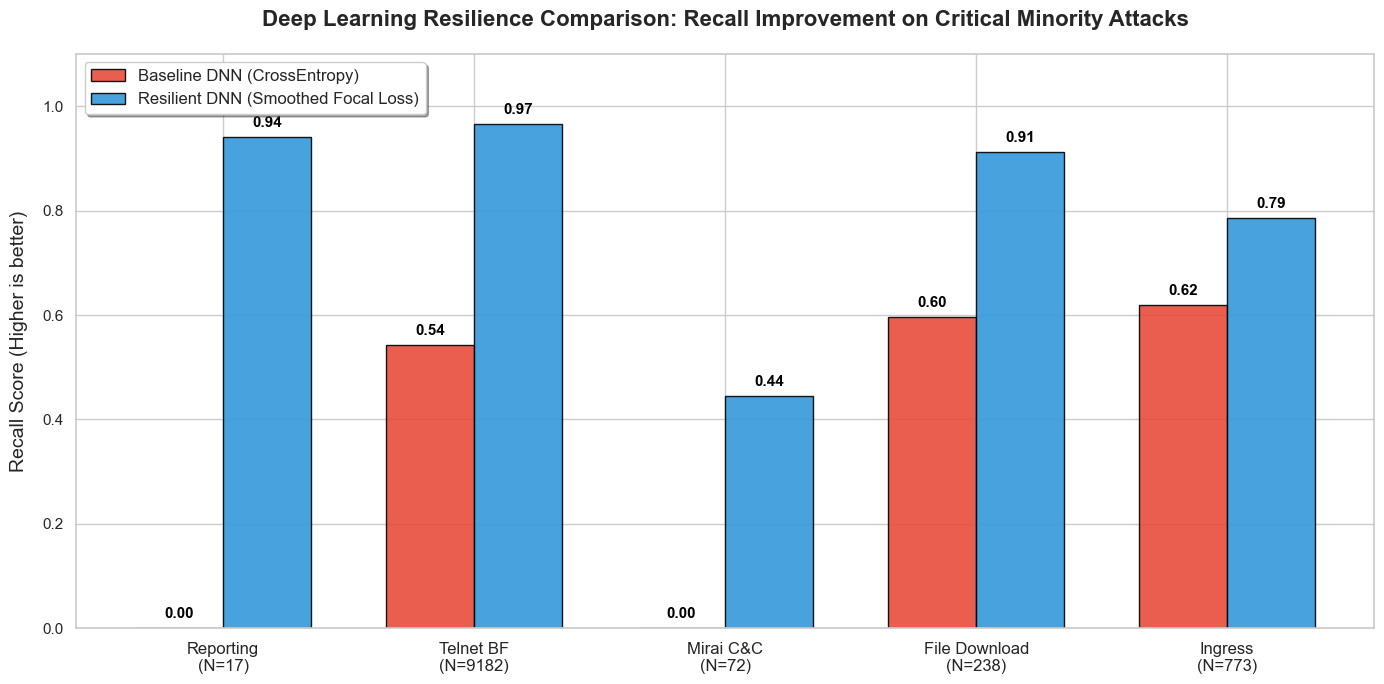

In [6]:
# Cell 6: Visualizing Critical Resilience Improvements on Target Minority Classes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import recall_score
import numpy as np

# Setting a clean aesthetic theme
sns.set_theme(style="whitegrid")

# Define target classes for direct performance comparison (Focused on hardest minority samples)
target_classes = [
    'Reporting', 
    'Telnet Brute Force', 
    'Mirai C&C Communication', 
    'File Download', 
    'Ingress Tool Transfer'
]

# Map target names to their encoded indices
class_indices = [np.where(label_encoder.classes_ == cls)[0][0] for cls in target_classes]

# Extract undiluted recalls (without averaging) from both runs
recalls_baseline_full = recall_score(all_ground_truth, all_predictions, average=None)
recalls_resilient_full = recall_score(all_ground_truth, all_predictions_v2, average=None)

# Standardize values for plotting (handling edge cases from zero-division report)
def get_clean_recall(recall_array, target_idx):
    if target_idx < len(recall_array):
        return recall_array[target_idx]
    return 0.0

# Retrieve specific recalls for our target classes
recalls_baseline_filtered = [get_clean_recall(recalls_baseline_full, idx) for idx in class_indices]
recalls_resilient_filtered = [get_clean_recall(recalls_resilient_full, idx) for idx in class_indices]

# Define visualization labels (using shorthands for better fit)
display_labels = ['Reporting\n(N=17)', 'Telnet BF\n(N=9182)', 'Mirai C&C\n(N=72)', 'File Download\n(N=238)', 'Ingress\n(N=773)']

# Grouped Bar Chart Configuration
x = np.arange(len(display_labels))  # Class locations
width = 0.35  # Bar width

fig, ax = plt.subplots(figsize=(14, 7))

# Baseline Bars (Red tones for imbalanced performance)
rects1 = ax.bar(x - width/2, recalls_baseline_filtered, width, label='Baseline DNN (CrossEntropy)', color='#e74c3c', edgecolor='black', alpha=0.9)

# Resilient Bars (Blue tones for improved performance via Smoothed Focal Loss)
rects2 = ax.bar(x + width/2, recalls_resilient_filtered, width, label='Resilient DNN (Smoothed Focal Loss)', color='#3498db', edgecolor='black', alpha=0.9)

# Labeling, Formatting, and Aesthetics
ax.set_title('Deep Learning Resilience Comparison: Recall Improvement on Critical Minority Attacks', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Recall Score (Higher is better)', fontsize=14, labelpad=10)
ax.set_ylim(0, 1.1)  # Set limit above 1 to accommodate labels

# Setting X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(display_labels, fontsize=12, fontweight='medium')
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Helper function to add numerical labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()